# AI и студенческая жизнь 2026: регрессия на реальных данных

**Задача:** от EDA до честного вердикта.

Датасет: `AI_Impact_Student_Life_2026.csv` — 1500 студентов, 11 признаков.

**Кандидаты в целевую переменную (target):**
- `GPA_Post_AI` — но осторожно: `GPA_Baseline` почти равен ей → утечка / тривиальный R². Хороший сюжет для честного вердикта.
- `Career_Confidence_Score` — уверенность в карьере.
- `Time_Saved_Hours_Weekly` — сэкономленные часы.

**Категориальные (object):** Major, Primary_AI_Tool, Main_Usage_Case, AI_Ethics_Concern.  
**Не признак:** Student_ID (идентификатор).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv("data/AI_Impact_Student_Life_2026.csv")
df.shape

(1500, 11)

In [4]:
df.head()

,Student_ID,Age,Major,Primary_AI_Tool,Task_Frequency_Daily,Main_Usage_Case,GPA_Baseline,GPA_Post_AI,Time_Saved_Hours_Weekly,AI_Ethics_Concern,Career_Confidence_Score
0,STU-6019,23,Software Engineering,Gemini Pro,1,Code Debugging,2.62,2.62,9,Medium,3
1,STU-6962,22,Modern History,GitHub Copilot,3,Essay Drafting,3.99,4.00,7,Medium,4
2,STU-2338,18,Data Science,Perplexity,2,Literature Review,2.57,2.57,15,High,7
3,STU-1380,19,Biology,Claude 3.5,5,Essay Drafting,2.67,2.87,12,Low,5
4,STU-1837,19,Biology,ChatGPT-4o,10,Code Debugging,3.65,3.85,5,High,9


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Student_ID               1500 non-null   object 
 1   Age                      1500 non-null   int64  
 2   Major                    1500 non-null   object 
 3   Primary_AI_Tool          1500 non-null   object 
 4   Task_Frequency_Daily     1500 non-null   int64  
 5   Main_Usage_Case          1500 non-null   object 
 6   GPA_Baseline             1500 non-null   float64
 7   GPA_Post_AI              1500 non-null   float64
 8   Time_Saved_Hours_Weekly  1500 non-null   int64  
 9   AI_Ethics_Concern        1500 non-null   object 
 10  Career_Confidence_Score  1500 non-null   int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 129.0+ KB


In [6]:
df.describe(include="all")

,Student_ID,Age,Major,Primary_AI_Tool,Task_Frequency_Daily,Main_Usage_Case,GPA_Baseline,GPA_Post_AI,Time_Saved_Hours_Weekly,AI_Ethics_Concern,Career_Confidence_Score
count,1500,1500.000000,1500,1500,1500.000000,1500,1500.000000,1500.000000,1500.00000,1500,1500.000000
unique,1500,NaN,6,5,NaN,5,NaN,NaN,NaN,3,NaN
top,STU-6019,NaN,Fine Arts,GitHub Copilot,NaN,Exam Prep,NaN,NaN,NaN,Low,NaN
freq,1,NaN,263,311,NaN,341,NaN,NaN,NaN,523,NaN
mean,NaN,21.494000,NaN,NaN,5.407333,NaN,3.256853,3.344587,8.51000,NaN,5.417333
std,NaN,2.297277,NaN,NaN,2.905462,NaN,0.430583,0.437409,4.07148,NaN,2.844977
min,NaN,18.000000,NaN,NaN,1.000000,NaN,2.500000,2.400000,2.00000,NaN,1.000000
25%,NaN,20.000000,NaN,NaN,3.000000,NaN,2.880000,2.980000,5.00000,NaN,3.000000
50%,NaN,21.000000,NaN,NaN,5.000000,NaN,3.260000,3.360000,9.00000,NaN,5.000000
75%,NaN,23.000000,NaN,NaN,8.000000,NaN,3.620000,3.710000,12.00000,NaN,8.000000


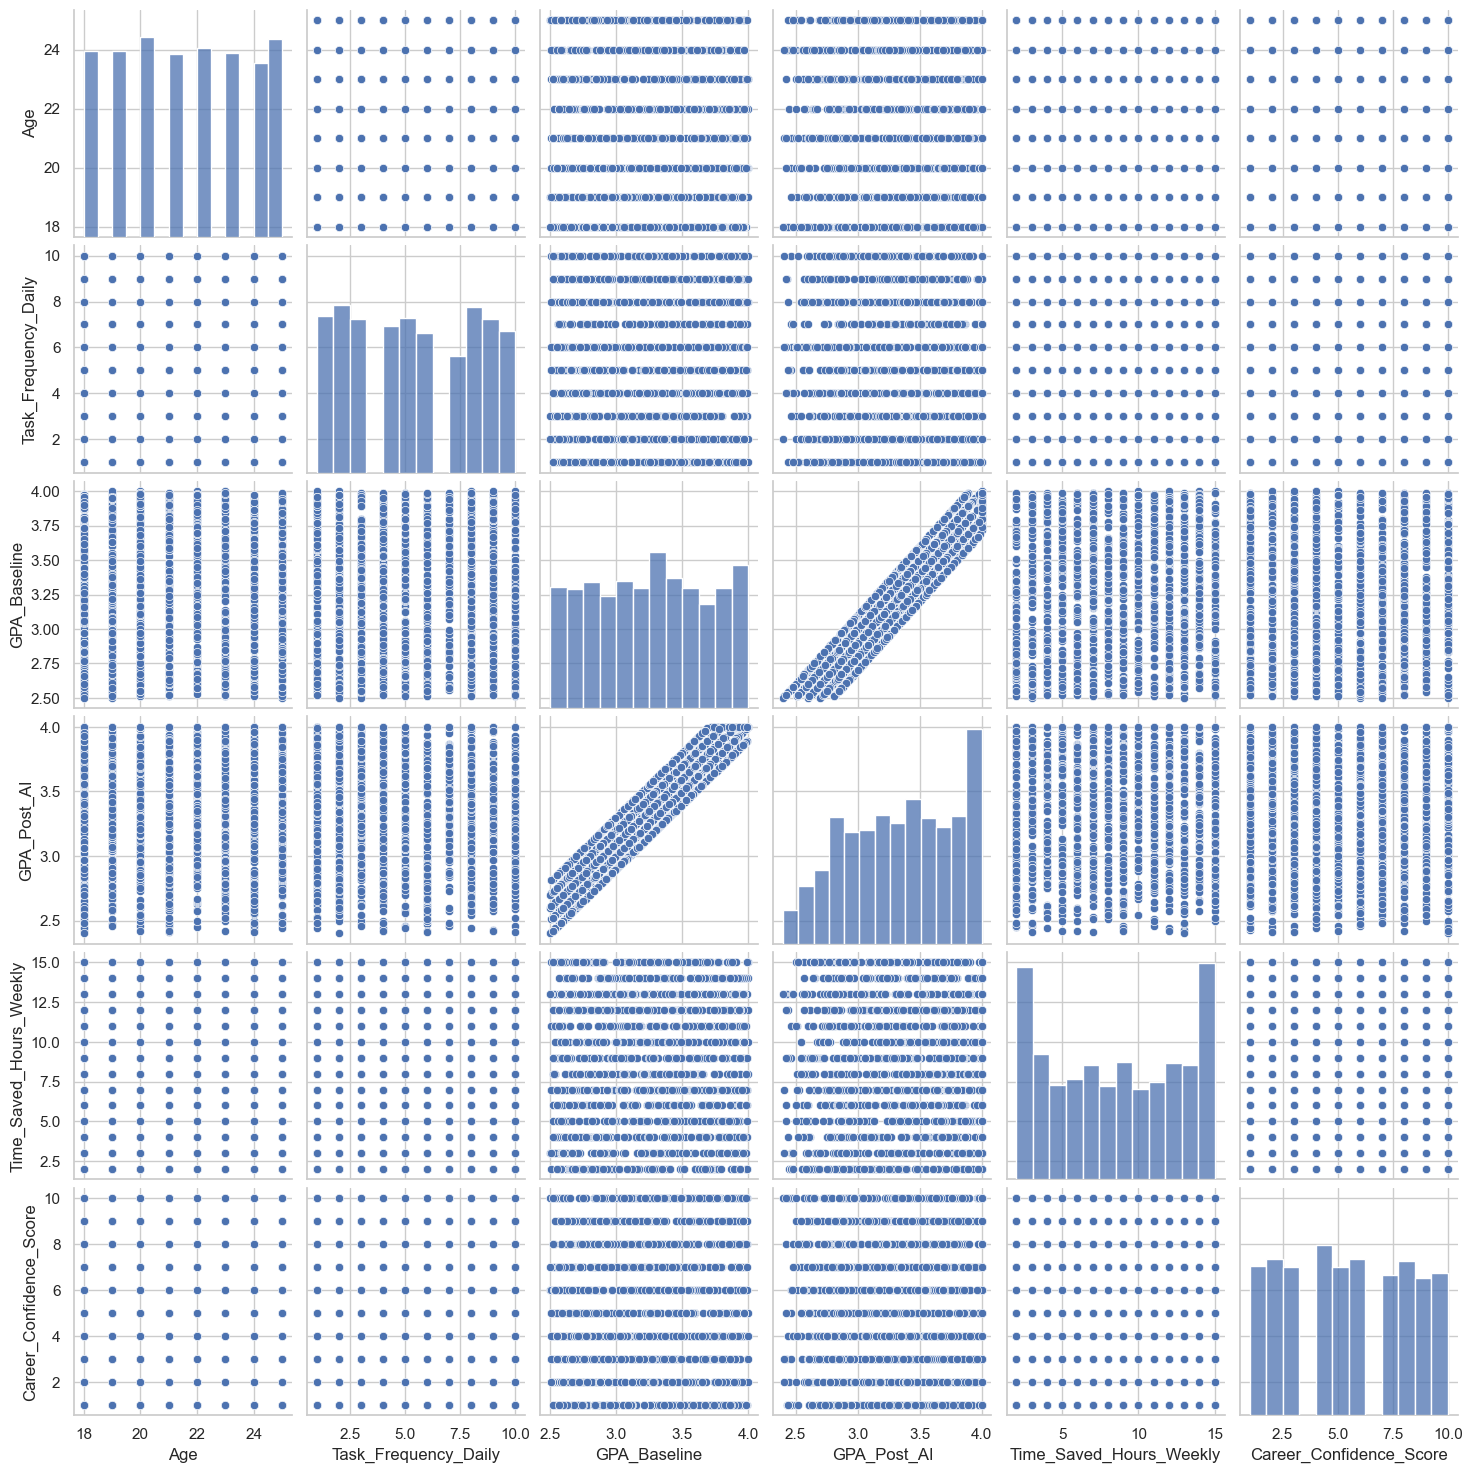

In [7]:
sns.pairplot(df)